# ML Model creation

In [1]:
import pandas as pd
import numpy as np

df =  pd.read_csv("tran_default.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Removing Outlierrs

In [3]:
df[df["person_emp_length"]> df["person_age"]]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


In [4]:
df = df[df["person_emp_length"]<=df["person_age"]]
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [5]:
df[df["person_emp_length"]> df["person_age"]]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length


In [6]:
df["person_age"].describe()

count    32414.000000
mean        27.747393
std          6.354105
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

In [8]:
df.shape

(32414, 12)

In [9]:
df= df[df["person_age"] < 100]

### Adding New features

In [12]:
income_bins = [0, 30000, 60000, 100000, float("inf") ]
income_labels = ["Low", "Lower Middle", "Upper Middle", "High"]
df["income_band"] = pd.cut(
    df["person_income"],
    bins= income_bins,
    labels=income_labels
)

In [14]:
age_bins = [18, 25, 35, 50, 100 ]
age_labels = ["18-25", "26-35", "36-50", "50+"]
df["age_band"] = pd.cut(
    df["person_age"],
    bins= age_bins,
    labels=age_labels
)

In [15]:
emp_bins = [-1, 2, 5, 10, 100 ]
emp_labels = ["New", "junior", "Mid", "Senior+"]
df["emp_band"] = pd.cut(
    df["person_emp_length"],
    bins= emp_bins,
    labels=emp_labels
)

In [16]:
rate_bins = [0,8,12,16,30]

rate_labels = [
    "Low",
    "Medium",
    "High",
    "Very High"
]

df["interest_category"] = pd.cut(
    df["loan_int_rate"],
    bins=rate_bins,
    labels=rate_labels
)

In [17]:
history_bins = [0,5,10,20,50]

history_labels = [
    "Short",
    "Medium",
    "Long",
    "Very Long"
]

df["credit_history_category"] = pd.cut(
    df["cb_person_cred_hist_length"],
    bins=history_bins,
    labels=history_labels
)

### Converting categorical data to numeric

In [18]:
df["cb_person_default_on_file"] = (
    df["cb_person_default_on_file"]
    .map({"Y":1,"N":0})
)

In [20]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [21]:
X = pd.get_dummies(X, drop_first=True)

In [22]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32409 entries, 1 to 32415
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   person_age                         32409 non-null  int64  
 1   person_income                      32409 non-null  int64  
 2   person_emp_length                  32409 non-null  float64
 3   loan_amnt                          32409 non-null  int64  
 4   loan_int_rate                      32409 non-null  float64
 5   loan_percent_income                32409 non-null  float64
 6   cb_person_default_on_file          32409 non-null  int64  
 7   cb_person_cred_hist_length         32409 non-null  int64  
 8   person_home_ownership_OTHER        32409 non-null  bool   
 9   person_home_ownership_OWN          32409 non-null  bool   
 10  person_home_ownership_RENT         32409 non-null  bool   
 11  loan_intent_EDUCATION              32409 non-null  bool   


# preparing Data for model Trainng

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
pred = lr.predict(X_test)

prob = lr.predict_proba(X_test)[:,1]

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test,pred))
print("Precision:", precision_score(y_test,pred))
print("Recall   :", recall_score(y_test,pred))
print("F1 Score :", f1_score(y_test,pred))
print("ROC AUC  :", roc_auc_score(y_test,prob))

Accuracy : 0.8639308855291576
Precision: 0.7533081285444234
Recall   : 0.5620592383638928
F1 Score : 0.6437802907915994
ROC AUC  : 0.8722390078365051


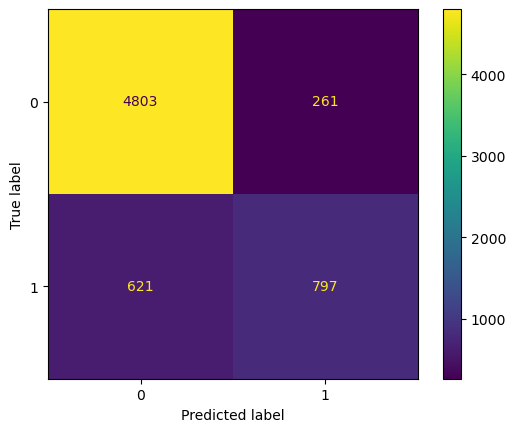

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)

plt.show()